<a href="https://colab.research.google.com/github/LeonardoMiele/FruitGrowth/blob/main/Tomate_PBE_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This notebook presents a numerical solver for a system of two Partial Differential Equations (PDEs) representing the dynamics of cell populations under certain biological processes. The system is given by:

\begin{align}
\frac{\partial n_P(t,x)}{\partial t} &= \Omega\left[n(t,\cdot)\right] \bigg\{ - \frac{\partial}{\partial x} \left[\phi(x)\,n_P(t,x)\right] + \gamma_0 \left[4\gamma(2x)\,n_P(t,2x) - \gamma(x)\,n_P(t,x)\right] \bigg\} - \rho\,n_P(t,x), \\
\frac{\partial n_Q(t,x)}{\partial t} &= \Omega\left[n(t,\cdot)\right] \bigg\{ -\frac{\partial}{\partial x} \left[\phi(x)\,n_Q(t,x)\right] \bigg\} + \rho\,n_P(t,x).
\end{align}

on a domain $x\in (0,L)$, with Dirichlet boundary conditions at $x=0$. Here, $n_P (t,x)$ and $n_Q (t,x)$ correspond to the densities at time $t$ of $P$ and $Q$ cells with size (mass) $x$, respectively.

**Main quantities**

The total population density: $n(t,x)=n_P (t,x)+n_Q (t,x)$

Total population:  $N(t)=\int_0^\infty n(t,x) dx$

Total mass:  $M(t)=\int_0^\infty x n(t,x) dx$

Total surface area, up to multiplication by the volumetric cell density: $S(t)=\int_0^\infty x^{2/3} n(t,x) dx$.

**Coefficients**

The size-dependent expansion function $\phi(x)$ describes the rate at which a cell of size $x$ increases its size and is chosen as:

\begin{equation}
    \phi(x)=x^{\frac{2}{3}},
\end{equation}

The functional term $\Omega[n(t,\cdot)]$, influencing growth based on available resources, is defined by:

\begin{equation}
\Omega[n(t,\cdot)]=\phi_0-\frac{\int \phi(x)\,n(t,x) dx}{\kappa},
\end{equation}

where $K$ represents the effective carrying capacity for the total resource demand that the environment can support.

The division function $\gamma(x)$, describing the division rate of a cell of size $x$, is given by:

\begin{equation}
    \gamma(x)=\gamma_0 \frac{x^{12}}{\chi^{12}+x^{12}},
\end{equation}

with $\gamma_0=223.2$.

**Inputs**

The model has four parameters $\theta= \{\phi_0, \rho, \kappa, \chi\}$ needing specification + the initial number of cells $N(0)$, the size $L$ of the domain and the final time $T$.

**Outputs**

The outputs are $n_P(t)$, $n_Q(t)$, $N(t)$, $M(t)$ at specified times and the spatial grid.

**Numerical method**

The numerical method uses an explicit Euler scheme in time (in order to deal with the nonlocal terms $S(t)$ and $n_P(t,2x)$).
It uses a non-uniform grid in space, with grid points more concentrated for small $x$ values
It deals separately with the transport and reaction terms, in two separate steps.
To deal with the transport equation, (1) we construct a spatial interpolation of the solution at time $t$ over $(0,L)$ (2) we compute the exact solution at time $t+dt$ based on the solution at time $t$.
To deal with the reaction term, we directly compute the terms in the right-hand side, and use an interpolation to compute the values at positions $2x$.


In [1]:
# required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import warnings

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
})

## Main solver

In [2]:
def solve_PBE_v1_plot(Theta, L, T, cell_num0, VT):
    # Define time step and spatial grid size
    dt = 0.01
    nxp = 4000

    # Create a non-uniform grid using hyperbolic tangent for better resolution at lower x values
    X = 1 + np.tanh(4 * (np.arange(-nxp // 2, nxp // 2 + 1) / nxp))
    X = X - X[0]
    dx0 = 1e-5 / L
    dx1 = 0.1 / L
    Y = dx0 + X * (dx1 - dx0)
    R = np.cumsum(Y)
    xx = R / max(R) * L
    xx = np.concatenate(([1e-6], xx))
    xs = np.diff(xx)

    # Extend grid for boundary conditions and interpolation close to the boundary
    xxneg = np.arange(-1, 0, 0.01)
    xxpos = np.arange(L + 0.5, 2 * L + 1, 0.5)

    # Time grid
    tt = np.arange(0, T + dt, dt)
    nx = len(xx)
    nt = len(tt)

    # Unpack parameters from Theta
    r, rho, K, h = Theta

    # Initial condition parameters
    x0 = 0.1
    K2 = 1e2
    kk = 223.2
    n = 12

    # Initial condition for cell densities
    nP = cell_num0 * np.sqrt(K2) * np.exp(-K2 * (xx - x0) ** 2) / np.sqrt(np.pi)
    nP[round(3 * len(nP) / 4):] = 0
    nQ = np.zeros_like(xx)

    # ============================================================
    # Precomputations for speed
    # ============================================================

    # Extended interpolation grid
    x_ext = np.concatenate((xxneg, xx, xxpos))
    nneg = len(xxneg)
    npos = len(xxpos)

    yP_ext = np.zeros(nneg + nx + npos)
    yQ_ext = np.zeros(nneg + nx + npos)

    # Powers of x
    xx_13 = xx ** (1 / 3)
    xx_23 = xx ** (2 / 3)

    xx2 = 2 * xx
    xx2_13 = xx2 ** (1 / 3)
    xx2_23 = xx2 ** (2 / 3)

    # Division rates
    h_n = h ** n
    gamma_x = kk * xx ** n / (h_n + xx ** n)
    gamma_2x = kk * xx2 ** n / (h_n + xx2 ** n)

    # Trapezoidal weights for N
    wN = np.zeros(nx)
    wN[:-1] += xs / 2
    wN[1:] += xs / 2

    # Trapezoidal-like weights exactly matching the original M formula
    x_mid = (xx[:-1] + xx[1:]) / 2
    wM = np.zeros(nx)
    wM[:-1] += x_mid * xs / 2
    wM[1:] += x_mid * xs / 2

    # Trapezoidal-like weights exactly matching the original S formula
    x23_mid = (xx_23[:-1] + xx_23[1:]) / 2
    wS = np.zeros(nx)
    wS[:-1] += x23_mid * xs / 2
    wS[1:] += x23_mid * xs / 2

    # Precompute saving indices instead of checking all VT values at every time step
    save_steps = np.rint(VT / dt).astype(int)
    valid = (
        (save_steps >= 1)
        & (save_steps < nt)
        & (np.abs(tt[save_steps] - VT) < dt / 2)
    )
    save_steps = save_steps[valid]
    save_cols = np.arange(len(VT))[valid]
    save_counter = 0
    n_saves = len(save_steps)

    # Initialize arrays
    NPtot = np.zeros(nt)
    NQtot = np.zeros(nt)
    M = np.zeros(nt)
    S = np.zeros(nt)
    Omega_t = np.zeros(nt)

    # Set initial values
    NPtot[0] = np.dot(nP, wN)
    NQtot[0] = np.dot(nQ, wN)

    ntotal = nP + nQ
    M[0] = np.dot(ntotal, wM)
    S[0] = np.dot(ntotal, wS)

    Omega_t[0] = r - S[0] / K

    # Initialize arrays for interpolated cell densities
    nnP = np.zeros((nx, len(VT)))
    nnQ = np.zeros((nx, len(VT)))

    # ============================================================
    # Main simulation loop
    # ============================================================

    for i in range(1, nt):
        # Current resource limitation value
        omega = r - S[i - 1] / K

        # Update extended arrays for interpolation
        yP_ext[nneg:nneg + nx] = nP
        yQ_ext[nneg:nneg + nx] = nQ

        # ------------------------------------------------------------
        # Characteristic transport step at x
        # ------------------------------------------------------------
        a_x = 3 * xx_13 - dt * omega
        x_back = (a_x ** 3) / 27
        factor_x = (a_x ** 2) / (9 * xx_23)

        nP_transport = factor_x * np.interp(
            x_back,
            x_ext,
            yP_ext,
            left=0,
            right=0,
        )

        nQ_transport = factor_x * np.interp(
            x_back,
            x_ext,
            yQ_ext,
            left=0,
            right=0,
        )

        # ------------------------------------------------------------
        # Characteristic transport step at 2x
        # Needed for the division source term
        # ------------------------------------------------------------
        a_2x = 3 * xx2_13 - dt * omega
        x2_back = (a_2x ** 3) / 27
        factor_2x = (a_2x ** 2) / (9 * xx2_23)

        nP_transport_2x = factor_2x * np.interp(
            x2_back,
            x_ext,
            yP_ext,
            left=0,
            right=0,
        )

        # Update nP and nQ by transport
        nP = nP_transport
        nQ = nQ_transport

        # Apply differentiation and division
        nQ += dt * rho * nP

        nP += dt * (
            -omega * gamma_x * nP
            + 4 * omega * gamma_2x * nP_transport_2x
            - rho * nP
        )

        # Handle NaN values
        np.nan_to_num(nP, copy=False, nan=0.0)
        np.nan_to_num(nQ, copy=False, nan=0.0)

        # Ensure non-negative densities
        np.maximum(nP, 0, out=nP)
        np.maximum(nQ, 0, out=nQ)

        # Update total populations, masses, and resource demand
        NPtot[i] = np.dot(nP, wN)
        NQtot[i] = np.dot(nQ, wN)

        ntotal = nP + nQ
        M[i] = np.dot(ntotal, wM)
        S[i] = np.dot(ntotal, wS)

        Omega_t[i] = r - S[i] / K

        # Store densities at specified times
        if save_counter < n_saves and i == save_steps[save_counter]:
            col = save_cols[save_counter]
            nnP[:, col] = nP
            nnQ[:, col] = nQ
            save_counter += 1

    N = NPtot + NQtot
    M = M * 1e-6

    return xx, tt, nnP, nnQ, M, N, Omega_t


## Data (Cervil low fruit charge)

In [4]:
# Days

tobs = np.array([
    10, 10, 10, 12, 12, 12, 14, 14, 14, 15, 16, 17, 17,
    20, 20, 20, 20, 23, 23, 23, 28, 28, 29, 32, 32, 32,
    42, 43, 44, 48, 50, 50, 50, 51, 51
])

# Number of cells N(t)

Nobs = np.array([
    56204.6296296296, 95158.3333333333, 134446.666666667,
    425687.037037037, 304546.666666667, 361414.814814815,
    154401.851851852, 234668.518518519, 288411.111111111,
    317763.888888889, 686379.629629630, 821333.333333333,
    902111.111111111, 829074.074074074, 1195104.16666667,
    1509062.50000000, 1636250.00000000, 1681979.16666667,
    1530375.00000000, 1432366.07142857, 1724156.25000000,
    1600000.00000000, 1610000, 1673812.50000000,
    1508671.87500000, 1579166.66666667, 1409270.83333333,
    1629739.58333333, 1350000.00000000, 1583750,
    1543880.20833333, 1560572.91666667, 1413645.83333333,
    1474114.58333333, 1517250
])

# Total mass M(t)


Mobs = np.array([
    0.0048, 0.0042, 0.0068, 0.0356, 0.0151, 0.0292,
    0.0249, 0.0272, 0.061, 0.070, 0.409, 0.3515,
    0.3687, 0.9685, 1.260, 0.875, 1.090, 1.868,
    1.741, 2.142, 3.633, 3.999, 4.361, 4.321,
    3.8027, 4.1651, 5.386, 5.271, 5.088, 6.527,
    5.956, 5.226, 5.693, 5.657, 6.156
])

# Final cell size distribution

edges = np.array([
    0, 1.98, 3.96, 5.94, 7.92, 9.90, 11.88, 13.86,
    15.84, 17.82, 19.80, 21.78, 23.76, 25.74, 27.72,
    29.70, 31.68, 33.66, 35.64, 37.62, 39.60, 41.58,
    43.56, 45.54, 47.52, 49.50
])

counts = np.array([
    0.227943148297131, 0.107267363904532, 0.0670421024403326,
    0.0223473674801108, 0.0268168409761330, 0.00446947349602217,
    0.0178778939840887, 0.00893894699204434, 0.00893894699204434,
    0, 0.00446947349602217, 0.00446947349602218, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00446947349602216
])


## Results

In [5]:
# Solve dynamics with specified parameters

Thetapm = [0.3301, 0.6143, 9.8137e6, 0.1044]
L = 30
T = 51
cell_num0 = 3300
VT = np.arange(0.1, 51.1, 0.1)

xx, tt, nnP, nnQ, M, N, Omega_t = solve_PBE_v1_plot(
    Thetapm, L, T, cell_num0, VT
)

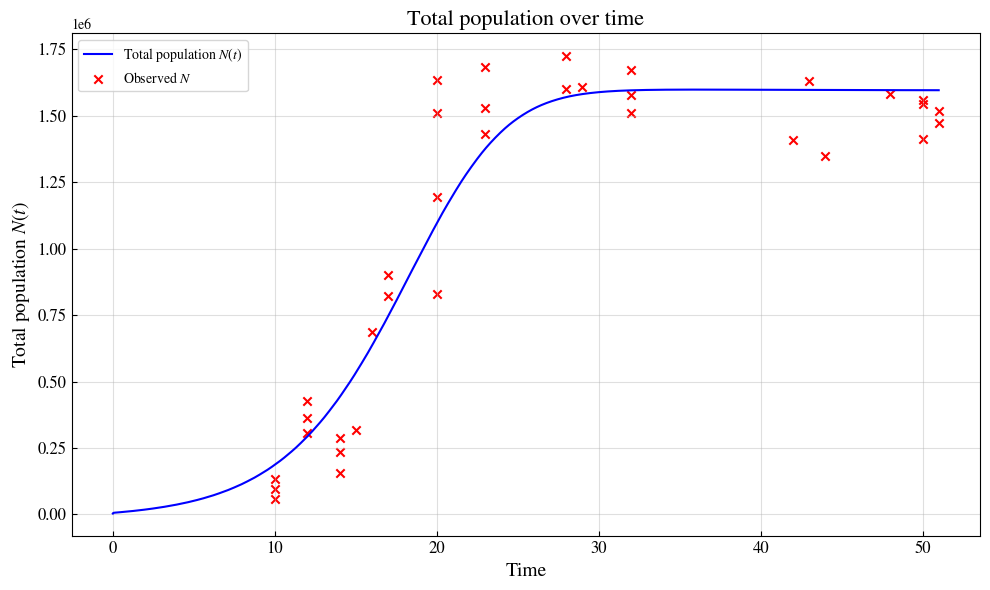

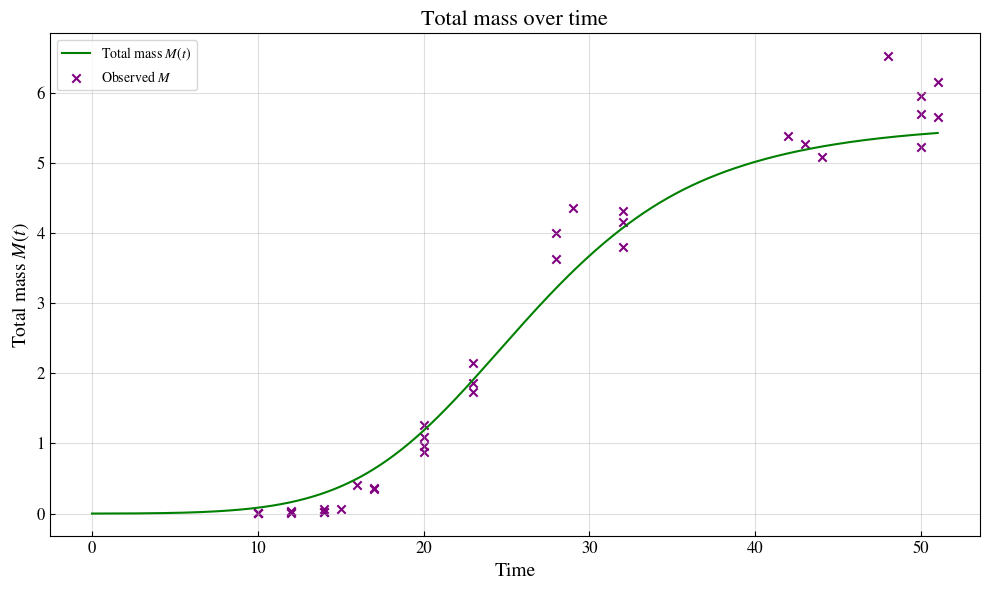

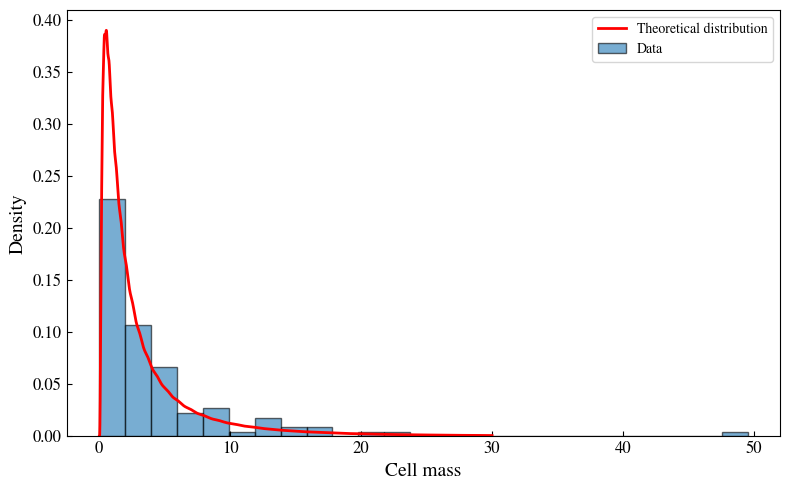

In [8]:
# Plot theoretical N(t) and data

plt.figure(figsize=(10, 6))
plt.plot(tt, N, label="Total population $N(t)$", color="blue")
plt.scatter(tobs, Nobs, color="red", marker="x", label="Observed $N$")
plt.xlabel("Time", fontsize=14)
plt.ylabel("Total population $N(t)$", fontsize=14)
plt.title("Total population over time", fontsize=16)
plt.tick_params(axis="both", direction="in", labelsize=12)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# Plot theoretical M(t) and data

plt.figure(figsize=(10, 6))
plt.plot(tt, M, label="Total mass $M(t)$", color="green")
plt.scatter(tobs, Mobs, color="purple", marker="x", label="Observed $M$")
plt.xlabel("Time", fontsize=14)
plt.ylabel("Total mass $M(t)$", fontsize=14)
plt.title("Total mass over time", fontsize=16)
plt.tick_params(axis="both", direction="in", labelsize=12)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# Plot theoretical final distribution and data

plt.figure(figsize=(8, 5))

plt.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    edgecolor="black",
    align="edge",
    alpha=0.6,
    label="Data",
)

plt.plot(
    xx,
    (nnP[:, -1] + nnQ[:, -1]) / N[-1],
    color="red",
    linewidth=2,
    label="Theoretical distribution",
)

plt.xlabel("Cell mass", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.tick_params(axis="both", direction="in", labelsize=12)
plt.legend()
plt.tight_layout()
plt.show()




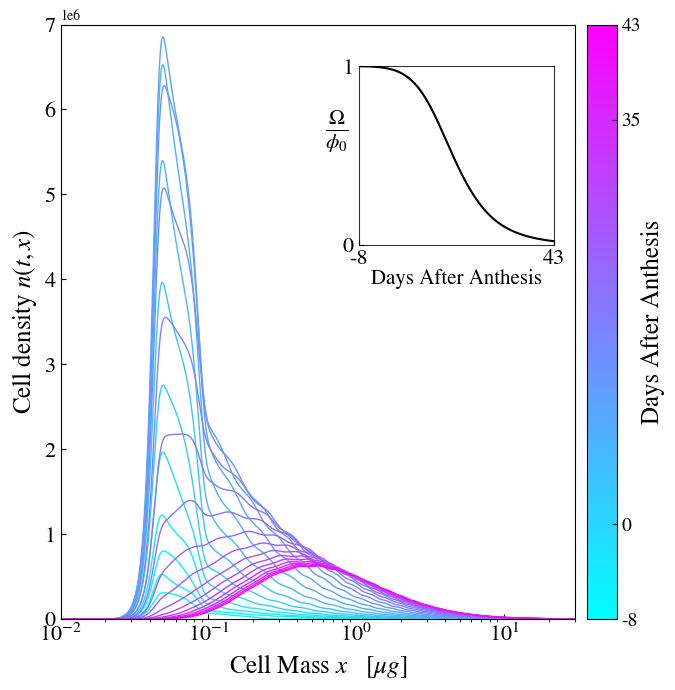

In [7]:
# Modelled cell size distribution dynamics with Omega inset

Timesplot = np.arange(0, 52, 2)
tol = 0.005

indices = [
    np.argmin(np.abs(VT - time))
    for time in Timesplot
    if np.abs(VT[np.argmin(np.abs(VT - time))] - time) < tol
]

VT2 = VT[indices]
nnP2 = nnP[:, indices]
nnQ2 = nnQ[:, indices]

nc = nnP2.shape[1]

cmap = plt.cm.cool
norm = plt.Normalize(vmin=0, vmax=Timesplot.max())

fig, ax = plt.subplots(figsize=(7, 7))

for i in range(nc):
    time = Timesplot[i] if i < len(Timesplot) else Timesplot[-1]
    ax.semilogx(
        xx,
        nnP2[:, i] + nnQ2[:, i],
        color=cmap(norm(time)),
        linewidth=1,
    )

ax.set_xlim([1e-2, 30])
ax.set_ylim([0, 7e6])
ax.set_xlabel(r"Cell Mass $x\quad[\mu g]$", fontsize=18)
ax.set_ylabel(r"Cell density $n(t,x)$", fontsize=18)
ax.set_xscale("log")
ax.tick_params(axis="both", labelsize=16, direction="in")

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Days After Anthesis", fontsize=18, rotation=90, labelpad=0.1)
cbar.set_ticks([0, 8, 42, 50])
cbar.set_ticklabels(["-8", "0", "35", "43"])
cbar.ax.tick_params(labelsize=14, direction="in")

# Inset: Omega over Days After Anthesis
tt_daa = tt - 8

axins = ax.inset_axes([0.58, 0.63, 0.38, 0.30])

axins.plot(tt_daa, Omega_t / Thetapm[0], color="black", linewidth=1.5)

axins.set_facecolor((1, 1, 1, 0.75))
axins.patch.set_alpha(0.75)

axins.set_xlabel("Days After Anthesis", fontsize=15, labelpad=0)
axins.set_ylabel(r"$\frac{\Omega}{\phi_0}$", fontsize=22, rotation=0)
axins.tick_params(axis="both", labelsize=9, direction="in")

axins.set_xticks([-8, 43])
axins.set_xticklabels(["-8", "43"])

axins.set_yticks([0, 1])
axins.set_yticklabels(["0", "1"])

axins.tick_params(axis="both", labelsize=16, direction="in")

axins.set_xlim([tt_daa.min(), tt_daa.max()])
axins.set_ylim([0, 1])

# Optional: make inset border slightly visible
for spine in axins.spines.values():
    spine.set_linewidth(0.8)
    spine.set_alpha(0.8)

warnings.filterwarnings("ignore")

plt.tight_layout()
plt.show()